# GISC 4381/6321 — Lab 4: Networks and Spatial Weights

**Week 4: Graph Theory & Spatial Weights**

In lecture we talked about two big ideas:

1. **Graphs/networks** — mathematical objects made of nodes and edges that can represent almost any kind of relationship (social ties, transactions, roads, friendships).
2. **Spatial weights** — a way of using that same graph/network idea to formally represent *"who is a neighbor of whom"* for spatial data, so we can compute things like spatial lag.

This notebook walks through both using two Python libraries:

- **[NetworkX](https://networkx.org/)** — general-purpose graph creation, analysis, and visualization.
- **[PySAL](https://pysal.org/) (`libpysal`)** — the Python Spatial Analysis Library, which we'll use specifically for its `weights` module.

Run each cell in order (Shift+Enter). Along the way you'll see **🔎 Try it yourself** boxes — short prompts to explore on your own.



In [ ]:
# !pip install libpysal  ## Run this once to install, then restart the kernel

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
import libpysal
from libpysal.weights import Queen, Rook, KNN, DistanceBand, higher_order, lag_spatial
from shapely.geometry import box

%matplotlib inline
plt.rcParams["figure.figsize"] = (5, 5)

/tmp/ipykernel_1038/2217427183.py:5: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


*You can ignore the ugly DeprecationWarning*

---
## Part 1: NetworkX Basics

### 1.1 Creating a graph

A `Graph` in NetworkX is undirected by default (edges go both ways). A `DiGraph` is directed.


In [2]:
G = nx.Graph()

# Add nodes individually or as a list
G.add_nodes_from(["A", "B", "C", "D", "E"])

# Add edges as (node, node) tuples
G.add_edges_from([("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"), ("D", "E")])

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))


Nodes: ['A', 'B', 'C', 'D', 'E']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'D'), ('D', 'E')]


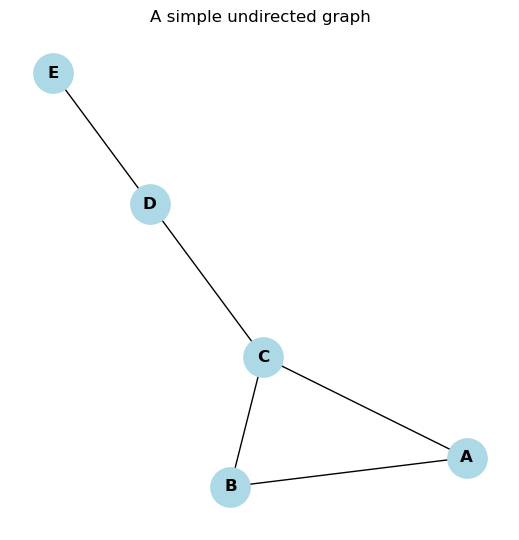

In [3]:
pos = nx.spring_layout(G, seed=42)  # a layout algorithm to decide where to draw nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=800, font_weight="bold")
plt.title("A simple undirected graph")
plt.show()


> **🔎 Try it yourself:** Add a new node `"F"` connected only to `"E"`. Redraw the graph. What changed
> about the shape/layout? (The `spring_layout` algorithm treats edges like springs pulling connected
> nodes together — this is why densely-connected nodes cluster and lightly-connected ones drift to the edge.)


### 1.2 Directed graphs

Recall from lecture: in a **directed graph**, an edge `A -> B` does *not* imply `B -> A`.


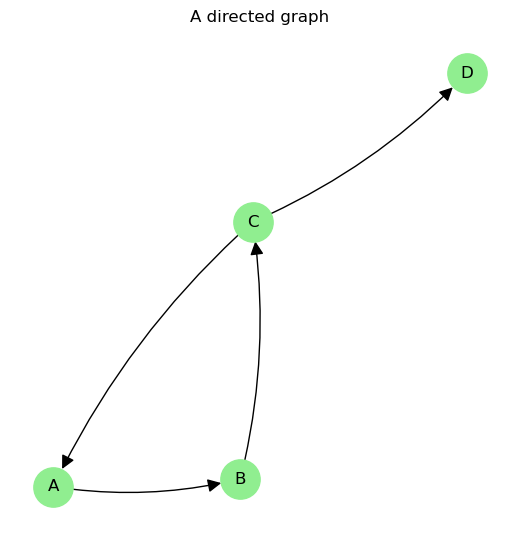

In [4]:
DG = nx.DiGraph()
DG.add_edges_from([("A", "B"), ("B", "C"), ("C", "A"), ("C", "D")])

pos = nx.spring_layout(DG, seed=1)
nx.draw(DG, pos, with_labels=True, node_color="lightgreen", node_size=800,
        arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.1")
plt.title("A directed graph")
plt.show()


In [5]:
print("Is DG strongly connected?", nx.is_strongly_connected(DG))
print("Is DG weakly connected?  ", nx.is_weakly_connected(DG))


Is DG strongly connected? False
Is DG weakly connected?   True


Strongly connected means you can get from *any* node to *any other* node **following edge
direction**. Weakly connected just means the graph would be connected if you ignored direction.
Node `D` only receives an edge and sends none — so DG can't be strongly connected, but it is
weakly connected.


### 1.3 Degree

The **degree** of a node is how many edges touch it.


In [6]:
print("Degree of each node:", dict(G.degree()))

degrees = [d for _, d in G.degree()]
print("Average degree:", sum(degrees) / len(degrees))


Degree of each node: {'A': 2, 'B': 2, 'C': 3, 'D': 2, 'E': 1}
Average degree: 2.0


### 1.4 The Friendship Paradox (revisited)

Lecture claimed: *on average, your friends have more friends than you do.* Let's simulate it on a
random graph and check.


In [7]:
ER = nx.erdos_renyi_graph(n=200, p=0.05, seed=1)  # 200 people, each pair connected w/ 5% chance

deg = dict(ER.degree())
avg_degree = sum(deg.values()) / len(deg)

friend_avgs = []
for node in ER.nodes():
    neighbors = list(ER.neighbors(node))
    if neighbors:
        friend_avgs.append(sum(deg[n] for n in neighbors) / len(neighbors))

print(f"Average degree in the network:        {avg_degree:.2f}")
print(f"Average degree of your friends:       {sum(friend_avgs)/len(friend_avgs):.2f}")


Average degree in the network:        10.25
Average degree of your friends:       11.35


> **🔎 Try it yourself:** Re-run the cell above with `p=0.02` and `p=0.15`. Does the *size* of the
> friendship-paradox gap grow or shrink as the network gets denser? Why might that be?


### 1.5 Weighted graphs and shortest paths

Edges can carry a `weight` — e.g., travel time, dollars exchanged, or number of shared crimes.


In [8]:
WG = nx.Graph()
WG.add_edge("A", "B", weight=4)
WG.add_edge("B", "C", weight=1)
WG.add_edge("A", "C", weight=10)

path = nx.shortest_path(WG, source="A", target="C", weight="weight")
length = nx.shortest_path_length(WG, source="A", target="C", weight="weight")
print("Shortest weighted path A -> C:", path, "| total weight:", length)

# Compare to the *unweighted* shortest path (i.e., fewest hops)
path_hops = nx.shortest_path(WG, source="A", target="C")
print("Shortest path by hop count:  ", path_hops)


Shortest weighted path A -> C: ['A', 'B', 'C'] | total weight: 5
Shortest path by hop count:   ['A', 'C']


Notice these two answers disagree! `A -> C` directly is only 1 hop, but going through `B` is
*cheaper* in total weight (4 + 1 = 5 < 10). This is exactly the airfare example from lecture:
fewest connections vs. shortest total time are different questions.


### 1.6 Centrality

Centrality measures try to answer *"which nodes are most important?"* — but "important" can mean
different things:

- **Degree centrality**: who has the most direct connections?
- **Closeness centrality**: who can reach everyone else the fastest, on average?
- **Betweenness centrality**: who sits on the most shortest paths between other pairs (i.e., who's
  a bridge/broker)?


In [9]:
# A graph with an obvious 'bridge' node to make the differences visible
BG = nx.Graph()
BG.add_edges_from([
    ("A1", "A2"), ("A1", "A3"), ("A2", "A3"),      # a triangle cluster
    ("A3", "Bridge"),
    ("Bridge", "B1"),
    ("B1", "B2"), ("B1", "B3"), ("B2", "B3"),      # another triangle cluster
])

dc = nx.degree_centrality(BG)
cc = nx.closeness_centrality(BG)
bc = nx.betweenness_centrality(BG)

for node in BG.nodes():
    print(f"{node:8s}  degree={dc[node]:.2f}  closeness={cc[node]:.2f}  betweenness={bc[node]:.2f}")


A1        degree=0.33  closeness=0.40  betweenness=0.00
A2        degree=0.33  closeness=0.40  betweenness=0.00
A3        degree=0.50  closeness=0.55  betweenness=0.53
Bridge    degree=0.33  closeness=0.60  betweenness=0.60
B1        degree=0.50  closeness=0.55  betweenness=0.53
B2        degree=0.33  closeness=0.40  betweenness=0.00
B3        degree=0.33  closeness=0.40  betweenness=0.00


In [ ]:
pos = nx.spring_layout(BG, seed=7)
node_size = [5000 * bc[n] + 300 for n in BG.nodes()]  # size nodes by betweenness
nx.draw(BG, pos, with_labels=True, node_size=node_size, node_color="salmon")
plt.title("Node size scaled by betweenness centrality")
plt.show()


`Bridge` has *low* degree centrality (only 2 connections) but the *highest* betweenness — nearly
every shortest path between the two triangle clusters has to pass through it. This is the node
whose removal would do the most damage to the network's connectivity.

> **🔎 Try it yourself:** Remove the `Bridge` node (`BG.remove_node("Bridge")`) and check
> `nx.is_connected(BG)`. What happens to the two clusters?


### 1.7 Adjacency matrices

Any graph can be represented as a matrix, where a 1 (or a weight) in row *i*, column *j* means
there's an edge from node *i* to node *j*. This is the exact same idea as the spatial weight
matrix we're about to build with PySAL!


In [10]:
nodelist = sorted(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodelist)
print("Node order:", nodelist)
print(A)


Node order: ['A', 'B', 'C', 'D', 'E']
[[0. 1. 1. 0. 0.]
 [1. 0. 1. 0. 0.]
 [1. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]


---
## Part 2: Spatial Weights with PySAL

Now we'll build the *spatial* version of an adjacency matrix: a **spatial weight matrix**, where
"neighbor" is defined geographically instead of socially.

We'll make a small synthetic dataset — a 4×4 grid of square polygons — so the neighbor
relationships are easy to see and verify by eye, before you try this on real shapefiles.


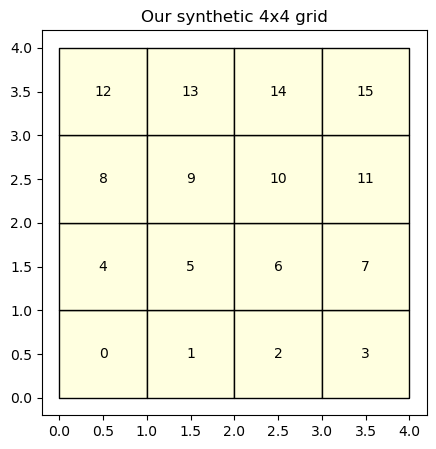

In [11]:
n_side = 4
polys, ids = [], []
for row in range(n_side):
    for col in range(n_side):
        polys.append(box(col, row, col + 1, row + 1))  # unit square at (col, row)
        ids.append(row * n_side + col)

gdf = gpd.GeoDataFrame({"id": ids}, geometry=polys)
gdf["group"] = ["North" if row < 2 else "South"
                 for row in [i // n_side for i in ids]]  # split grid into two halves for later

ax = gdf.plot(edgecolor="black", facecolor="lightyellow", figsize=(5, 5))
for i, geom in zip(gdf["id"], gdf.geometry):
    ax.annotate(str(i), (geom.centroid.x, geom.centroid.y), ha="center", va="center")
ax.set_title("Our synthetic 4x4 grid")
plt.show()


### 2.1 Contiguity weights: Rook vs. Queen

Recall from lecture: **rook** contiguity requires sharing an *edge* (a border); **queen**
contiguity also counts sharing just a *corner*.


In [12]:
w_rook = Rook.from_dataframe(gdf, use_index=False)
w_queen = Queen.from_dataframe(gdf, use_index=False)

print("Cell 0 (a corner cell) — rook neighbors: ", w_rook.neighbors[0])
print("Cell 0 (a corner cell) — queen neighbors:", w_queen.neighbors[0])
print()
print("Cell 5 (an interior cell) — rook neighbors: ", w_rook.neighbors[5])
print("Cell 5 (an interior cell) — queen neighbors:", w_queen.neighbors[5])
print()
print("Average number of neighbors — rook: ", w_rook.mean_neighbors)
print("Average number of neighbors — queen:", w_queen.mean_neighbors)


Cell 0 (a corner cell) — rook neighbors:  [1, 4]
Cell 0 (a corner cell) — queen neighbors: [1, 4, 5]

Cell 5 (an interior cell) — rook neighbors:  [1, 4, 6, 9]
Cell 5 (an interior cell) — queen neighbors: [0, 1, 2, 4, 6, 8, 9, 10]

Average number of neighbors — rook:  3.0
Average number of neighbors — queen: 5.25


For our 4×4 grid: a **corner** cell has 2 rook neighbors but 3 queen neighbors (the extra
diagonal). An **interior** cell has 4 rook neighbors but 8 queen neighbors. Queen contiguity is a
strict superset of rook — same idea as the UT/NW "are they touching" question from lecture, just
depends on whether corner-touching counts.

### 2.2 Visualizing the weight matrix as a network on the map

This is the exact bridge between Part 1 and Part 2: a spatial weight matrix *is* a graph, where
nodes are polygon centroids and edges connect neighbors.


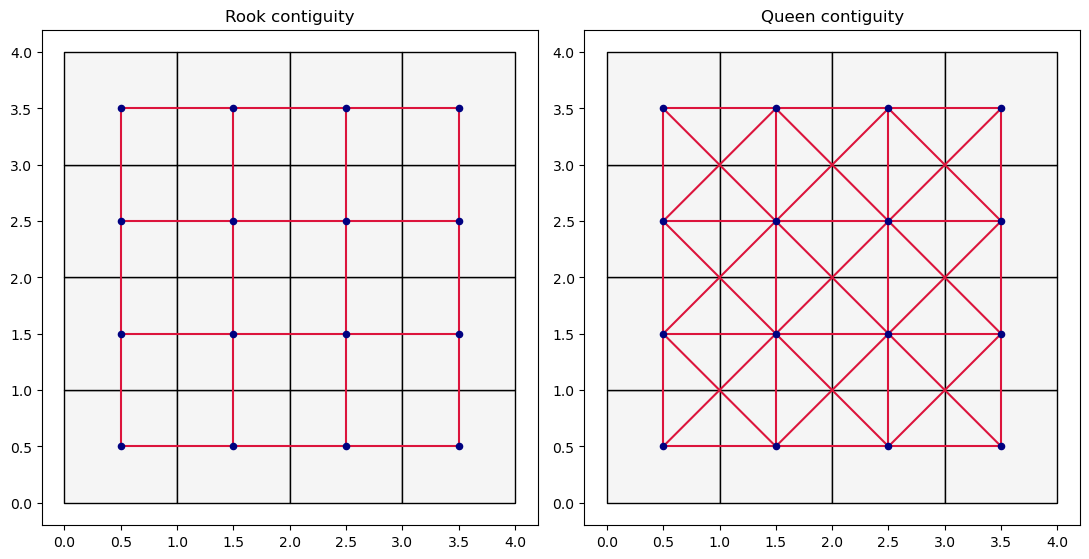

In [13]:
def plot_weights(gdf, w, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    gdf.plot(ax=ax, edgecolor="black", facecolor="whitesmoke")
    centroids = gdf.geometry.centroid
    for i, neighbors in w.neighbors.items():
        for j in neighbors:
            if j > i:  # avoid drawing each edge twice
                x = [centroids.iloc[i].x, centroids.iloc[j].x]
                y = [centroids.iloc[i].y, centroids.iloc[j].y]
                ax.plot(x, y, color="crimson", linewidth=1.5, zorder=1)
    centroids.plot(ax=ax, color="navy", markersize=20, zorder=2)
    ax.set_title(title)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_weights(gdf, w_rook, "Rook contiguity", ax=axes[0])
plot_weights(gdf, w_queen, "Queen contiguity", ax=axes[1])
plt.tight_layout()
plt.show()


> **🔎 Try it yourself:** Convert `w_queen` into a genuine NetworkX graph — hint:
> `nx.Graph(w_queen.neighbors)` works because `w.neighbors` is already a dict of
> `{node: [neighbor list]}`, which is exactly what `nx.Graph()` accepts as an adjacency dict.
> Then run `nx.degree_centrality()` on it. Which cells are most "central" in a 4x4 grid, and does
> that match your intuition?


### 2.3 Distance-based weights: KNN and Distance Band

Contiguity requires shapes with borders. If you only have points (e.g., store locations, crime
incidents), you need a distance-based definition of "neighbor" instead.


In [14]:
centroids_gdf = gpd.GeoDataFrame({"id": gdf["id"]}, geometry=gdf.geometry.centroid)

w_knn2 = KNN.from_dataframe(centroids_gdf, k=2)
w_dband = DistanceBand.from_dataframe(centroids_gdf, threshold=1.0)  # unit grid spacing = 1

print("KNN (k=2) neighbors of cell 0: ", w_knn2.neighbors[0])
print("Distance-band (<=1.0) neighbors of cell 0:", w_dband.neighbors[0])


KNN (k=2) neighbors of cell 0:  [4, 1]
Distance-band (<=1.0) neighbors of cell 0: [1, 4]


/home/jovyan/.local/iguide/lib/python3.8/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  warnings.warn(message)


Notice `DistanceBand` with `threshold=1.0` reproduces rook contiguity here (only directly
adjacent cells are within 1 grid unit) — distance-based and contiguity-based weights can agree
for a regular grid, but they diverge fast on irregular real-world polygons (think of Hawaii in
the lecture's KNN example, or a huge rural county vs. a tiny urban one).

> **🔎 Try it yourself:** Change `threshold` to `1.5` (captures diagonal neighbors too) and then to
> `0.5` (nothing is close enough). What happens to cells with 0 neighbors — what does lecture call
> those ("islands")? Why is that a problem for spatial statistics?


### 2.4 Block weights

Block weights connect everything that shares a group label — no geometry required at all.


In [15]:
from libpysal.weights import block_weights

w_block = block_weights(gdf["group"].values, ids=list(gdf["id"]))
print("Block-weight neighbors of cell 0 (North half):", sorted(w_block.neighbors[0]))


Block-weight neighbors of cell 0 (North half): [1, 2, 3, 4, 5, 6, 7]


Every "North" cell is connected to every other "North" cell, and likewise for "South" — this is
the tracts-in-a-county / counties-in-a-state idea from lecture. You'll often **combine** this with
a contiguity or distance weight (e.g., "neighboring AND in the same county") rather than use it
alone.


### 2.5 The connectivity histogram

A quick sanity check on *any* weight matrix before you use it: how many neighbors does the
typical observation have, and are there troubling outliers (islands, or one mega-hub)?


Queen weights histogram (cardinality, count): [(3, 4), (4, 0), (5, 8), (6, 0), (7, 0), (8, 4)]


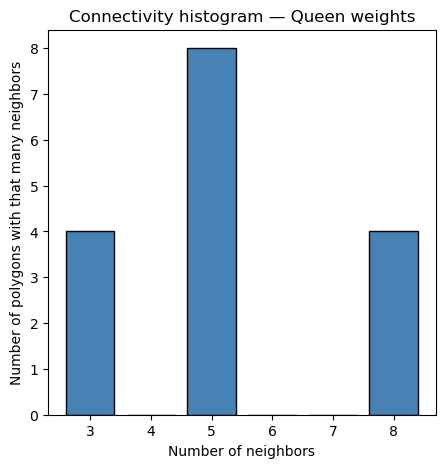

In [16]:
print("Queen weights histogram (cardinality, count):", w_queen.histogram)

card = [len(v) for v in w_queen.neighbors.values()]
plt.bar(*zip(*w_queen.histogram), color="steelblue", edgecolor="black")
plt.xlabel("Number of neighbors")
plt.ylabel("Number of polygons with that many neighbors")
plt.title("Connectivity histogram — Queen weights")
plt.show()


### 2.6 Higher-order contiguity

Sometimes you want "neighbors of neighbors," not just direct neighbors.


In [17]:
w_rook_order2 = higher_order(w_rook, k=2)
print("2nd-order rook neighbors of cell 0:", w_rook_order2.neighbors[0])
print("(compare to 1st-order:              ", w_rook.neighbors[0], ")")


2nd-order rook neighbors of cell 0: [2, 5, 8]
(compare to 1st-order:               [1, 4] )


### 2.7 Row standardization and spatial lag

Right now our weights are **binary** (1 if neighbor, 0 if not). For spatial lag, we usually
**row-standardize** first, so each row of the weight matrix sums to 1 — turning "sum of
neighboring values" into a proper weighted *average*.


In [18]:
w_queen.transform = "r"  # 'r' = row-standardized

# a made-up attribute, e.g. house prices in $1000s, higher in the north
np.random.seed(0)
gdf["price"] = [250 + 20 * (i // n_side) + np.random.normal(0, 5) for i in gdf["id"]]

gdf["price_lag"] = lag_spatial(w_queen, gdf["price"])

gdf[["id", "group", "price", "price_lag"]]


,id,group,price,price_lag
0,0,North,258.820262,265.484062
1,1,North,252.000786,266.583159
2,2,North,254.893690,264.462504
3,3,North,261.204466,266.295782
4,4,North,279.337790,271.494311
5,5,North,265.113611,274.007511
6,6,North,274.750442,272.812543
7,7,North,269.243214,275.768037
8,8,South,289.483906,292.183591
9,9,South,292.052993,292.004856


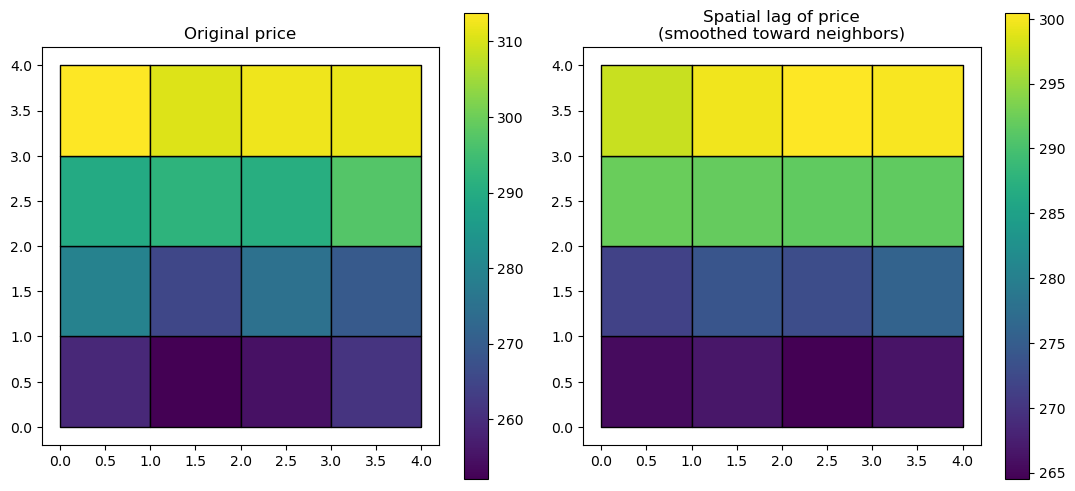

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
gdf.plot(column="price", ax=axes[0], legend=True, edgecolor="black", cmap="viridis")
axes[0].set_title("Original price")
gdf.plot(column="price_lag", ax=axes[1], legend=True, edgecolor="black", cmap="viridis")
axes[1].set_title("Spatial lag of price\n(smoothed toward neighbors)")
plt.tight_layout()
plt.show()


Compare the two maps: the spatial lag is a *smoothed* version of the original — exactly the
"realtor finds nearby comparable houses and averages them" idea from lecture. It pulls extreme
values toward their neighborhood's average.

> **🔎 Try it yourself:** Recompute `price_lag` using `w_rook` (row-standardized) instead of
> `w_queen`. Does using fewer neighbors (rook) make the lag *more* or *less* smoothed compared to
> queen? Why would that make sense given how spatial lag is calculated?


---
## Learn More / Going Further

This notebook only scratches the surface. If you want to go deeper on your own:

**Readings (from this week's syllabus):**
- *Geographic Data Science with Python*, Ch. 5, "Spatial Weights": https://geographicdata.science/book/notebooks/03_spatial_data.html
- *Spatial Data Science for Social Geography*, "Spatial Data": https://martinfleischmann.net/sds/geographic_data/concepts.html

**NetworkX:**
- Try loading a real dataset — NetworkX ships several in `nx.karate_club_graph()` (a classic
  social network dataset) and can also read edge lists directly from CSVs (`nx.read_edgelist`).
- Explore other centrality measures: `nx.eigenvector_centrality`, `nx.pagerank` (yes, the same
  algorithm behind early Google search).
- Try `nx.community.louvain_communities()` to automatically detect clusters/communities in a graph.
- If you want to explore the Seven Bridges of Königsberg problem computationally, look at
  `nx.is_eulerian()` and `nx.eulerian_circuit()`.

**PySAL / libpysal:**
- Try this on **real data**: `libpysal.examples.available()` lists built-in example datasets you
  can load with `libpysal.examples.load_example("Guerry")` (19th-century France) or
  `"Columbus"` (crime data) — both come with shapefiles ready to go.
- Explore `Kernel` weights (`libpysal.weights.Kernel`), which give closer neighbors *more* weight
  instead of a hard 0/1 cutoff — a middle ground between distance-band and pure contiguity.
- The broader **PySAL** ecosystem includes `esda` (spatial autocorrelation statistics like
  Moran's I, which uses spatial lag directly) and `spreg` (spatial regression) — both of which
  build on the weight matrices you just made.
- Try building weights for a *real* administrative boundary file (e.g., US Census tracts from
  `tigris` or a downloaded shapefile) and look at the connectivity histogram — real geography is
  messier than our grid!

**A bigger challenge, if you're interested:** combine both libraries. Build a spatial weight
matrix with `libpysal`, convert it to a NetworkX graph (`nx.Graph(w.neighbors)`), and run
betweenness centrality on it. Which regions in a real dataset act as "bridges" connecting
otherwise distant parts of the map?
